# 03 — Player Performance Index & Auction Valuation
## AuctionIQ — IPL Player Valuation & Auction Intelligence
**Goal:** Combine BPI and BoPI into a unified Player Value Score (PVS), identify allrounders, classify players by role, and build the auction valuation model that identifies overpriced vs undervalued players.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

# Load batting and bowling stats
batting = pd.read_csv('../data/processed/batting_stats.csv')
bowling = pd.read_csv('../data/processed/bowling_stats.csv')
master  = pd.read_csv('../data/processed/master_balls.csv')

print(f"✅ Data loaded")
print(f"   Batters : {len(batting)}")
print(f"   Bowlers : {len(bowling)}")
print(f"   Balls   : {len(master):,}")

✅ Data loaded
   Batters : 229
   Bowlers : 191
   Balls   : 287,513


In [2]:
# Merge batting and bowling stats
# Players appearing in both = allrounders
batting_cols = ['striker','innings','runs_scored','strike_rate',
                'batting_avg','consistency_score','recent_sr','BPI']
bowling_cols = ['bowler','matches','wickets','economy',
                'dot_pct','recent_economy','BoPI']

# Rename for merge
bat = batting[batting_cols].rename(columns={'striker':'player'})
bow = bowling[bowling_cols].rename(columns={'bowler':'player'})

# Full outer join — keeps all players
players = bat.merge(bow, on='player', how='outer')

# Classify role
def classify_role(row):
    has_bat = pd.notna(row['BPI']) and row.get('innings', 0) >= 20
    has_bowl = pd.notna(row['BoPI']) and row.get('wickets', 0) >= 20
    if has_bat and has_bowl:
        return 'Allrounder'
    elif has_bat:
        return 'Batter'
    elif has_bowl:
        return 'Bowler'
    else:
        return 'Unknown'

players['role'] = players.apply(classify_role, axis=1)

print(f"✅ Player roles classified")
print(f"\nRole distribution:")
print(players['role'].value_counts())
print(f"\nTotal players: {len(players)}")
print(f"\nSample allrounders:")
print(players[players['role']=='Allrounder'][
    ['player','innings','BPI','wickets','BoPI']
].head(10).to_string(index=False))

✅ Player roles classified

Role distribution:
role
Batter        148
Allrounder     81
Bowler         77
Unknown        14
Name: count, dtype: int64

Total players: 320

Sample allrounders:
       player  innings   BPI  wickets  BoPI
     A Mishra     55.0 30.09    174.0 61.17
    A Symonds     36.0 62.51     20.0 56.36
   AD Mathews     41.0 55.15     27.0 48.06
   AD Russell    114.0 80.01    123.0 56.46
     AR Patel    129.0 58.43    135.0 64.65
Azhar Mahmood     21.0 51.20     29.0 60.61
      B Kumar     73.0 25.54    212.0 73.75
    BA Stokes     43.0 56.63     28.0 51.46
    CH Morris     49.0 63.32     96.0 62.26
     DJ Bravo    110.0 56.43    183.0 55.96


In [3]:
# Player Value Score — unified metric combining BPI + BoPI
# Weighted by role — batters weighted on BPI, bowlers on BoPI, allrounders balanced

def calculate_pvs(row):
    bpi  = row['BPI']  if pd.notna(row['BPI'])  else 0
    bopi = row['BoPI'] if pd.notna(row['BoPI']) else 0
    role = row['role']

    if role == 'Batter':
        return round(bpi * 1.0, 2)
    elif role == 'Bowler':
        return round(bopi * 1.0, 2)
    elif role == 'Allrounder':
        # Allrounders get bonus for being dual-threat
        return round((bpi * 0.5) + (bopi * 0.5) + 5, 2)
    else:
        return 0

players['PVS'] = players.apply(calculate_pvs, axis=1)

# Final ranking
players = players[players['role'] != 'Unknown'].copy()
players = players.sort_values('PVS', ascending=False).reset_index(drop=True)
players['overall_rank'] = players.index + 1

print(f"✅ Player Value Score (PVS) calculated")
print(f"\nTop 25 Players by PVS:")
print(players.head(25)[
    ['overall_rank','player','role','innings','BPI','wickets','BoPI','PVS']
].to_string(index=False))

✅ Player Value Score (PVS) calculated

Top 25 Players by PVS:
 overall_rank          player       role  innings   BPI  wickets  BoPI   PVS
            1       H Klaasen     Batter     53.0 86.12      NaN   NaN 86.12
            2        TH David     Batter     51.0 83.83      NaN   NaN 83.83
            3         PD Salt     Batter     40.0 83.19      NaN   NaN 83.19
            4 B Sai Sudharsan     Batter     48.0 82.92      NaN   NaN 82.92
            5      Naman Dhir     Batter     26.0 82.32      NaN   NaN 82.32
            6        T Stubbs     Batter     37.0 82.23      NaN   NaN 82.23
            7        CV Varun     Bowler      NaN   NaN    107.0 80.37 80.37
            8     YBK Jaiswal     Batter     75.0 80.14      NaN   NaN 80.14
            9         TM Head     Batter     45.0 79.97      NaN   NaN 79.97
           10  Shashank Singh     Batter     38.0 79.38      NaN   NaN 79.38
           11        N Pooran     Batter     94.0 78.77      NaN   NaN 78.77
           12 

In [4]:
# Real IPL 2024 auction prices (in crores) for known players
# Source: public IPL auction data
auction_prices = {
    'MS Dhoni': 4.0, 'V Kohli': 17.0, 'RG Sharma': 16.0,
    'JJ Bumrah': 14.0, 'KL Rahul': 14.0, 'RR Pant': 16.0,
    'SP Narine': 13.25, 'AD Russell': 12.0, 'Rashid Khan': 18.0,
    'Shubman Gill': 12.5, 'YBK Jaiswal': 14.0, 'SA Yadav': 11.0,
    'HV Patel': 8.25, 'Arshdeep Singh': 4.0, 'Mohammed Siraj': 7.0,
    'R Ashwin': 5.0, 'RA Jadeja': 16.0, 'YS Chahal': 6.5,
    'B Sai Sudharsan': 8.25, 'Tilak Varma': 8.0,
    'Abhishek Sharma': 14.0, 'CV Varun': 1.7,
    'N Pooran': 6.0, 'JC Buttler': 15.0, 'CH Gayle': 2.0,
    'AR Patel': 9.5, 'DJ Bravo': 4.2, 'B Kumar': 2.4,
    'Kuldeep Yadav': 2.0, 'TA Boult': 8.0,
}

# Map prices to players
players['auction_price'] = players['player'].map(auction_prices)

# For valuation — only players with known prices
valued = players[players['auction_price'].notna()].copy()

# Normalise price to 0-100 scale
valued['n_price'] = ((valued['auction_price'] - valued['auction_price'].min()) /
                     (valued['auction_price'].max() - valued['auction_price'].min()) * 100).round(2)

# Value ratio — PVS per crore (higher = better value)
valued['value_ratio'] = (valued['PVS'] / valued['auction_price']).round(2)

# Valuation category
pvs_median   = valued['PVS'].median()
price_median = valued['auction_price'].median()

def valuation_tag(row):
    high_pvs   = row['PVS']   >= pvs_median
    high_price = row['auction_price'] >= price_median
    if high_pvs and not high_price:
        return 'Undervalued 💎'
    elif high_pvs and high_price:
        return 'Premium Value ⭐'
    elif not high_pvs and high_price:
        return 'Overvalued ⚠️'
    else:
        return 'Budget Pick 🔵'

valued['valuation'] = valued.apply(valuation_tag, axis=1)

print(f"✅ Auction valuation model built")
print(f"\nValuation distribution:")
print(valued['valuation'].value_counts())
print(f"\nTop UNDERVALUED players (High PVS, Low Price):")
print(valued[valued['valuation']=='Undervalued 💎'].nlargest(10,'value_ratio')[
    ['player','role','PVS','auction_price','value_ratio','valuation']
].to_string(index=False))
print(f"\nTop OVERVALUED players (Low PVS, High Price):")
print(valued[valued['valuation']=='Overvalued ⚠️'].nlargest(5,'auction_price')[
    ['player','role','PVS','auction_price','value_ratio','valuation']
].to_string(index=False))

✅ Auction valuation model built

Valuation distribution:
valuation
Premium Value ⭐    8
Budget Pick 🔵      8
Undervalued 💎      7
Overvalued ⚠️      7
Name: count, dtype: int64

Top UNDERVALUED players (High PVS, Low Price):
         player   role   PVS  auction_price  value_ratio     valuation
       CV Varun Bowler 80.37           1.70        47.28 Undervalued 💎
       CH Gayle Batter 75.94           2.00        37.97 Undervalued 💎
       MS Dhoni Batter 72.23           4.00        18.06 Undervalued 💎
       N Pooran Batter 78.77           6.00        13.13 Undervalued 💎
      YS Chahal Bowler 72.53           6.50        11.16 Undervalued 💎
B Sai Sudharsan Batter 82.92           8.25        10.05 Undervalued 💎
    Tilak Varma Batter 75.96           8.00         9.49 Undervalued 💎

Top OVERVALUED players (Low PVS, High Price):
   player       role   PVS  auction_price  value_ratio     valuation
  V Kohli     Batter 70.50           17.0         4.15 Overvalued ⚠️
RA Jadeja Allrounder 6

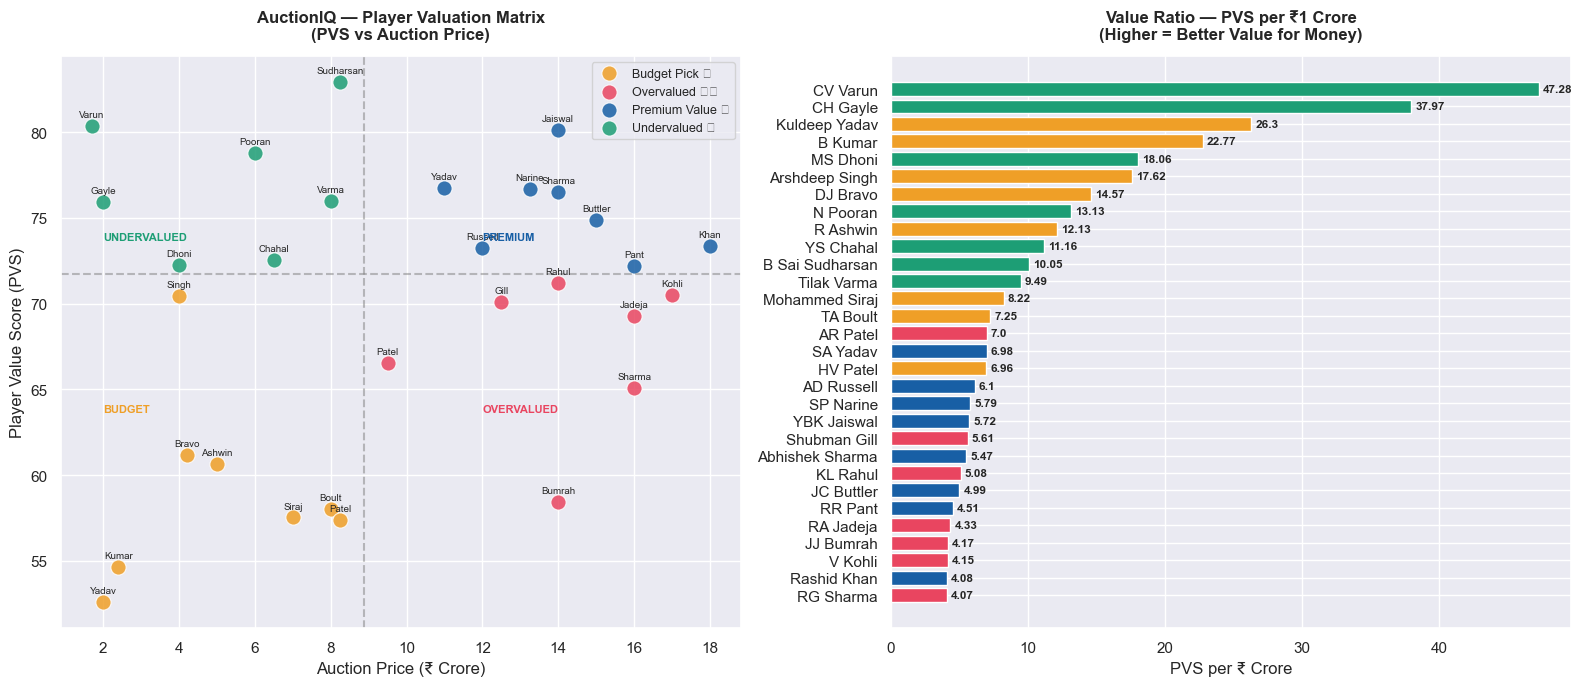

✅ Chart saved → screenshots/04_valuation_matrix.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 — PVS vs Price scatter (Valuation Matrix)
colors_map = {
    'Undervalued 💎'  : '#1D9E75',
    'Premium Value ⭐' : '#185FA5',
    'Overvalued ⚠️'   : '#E94560',
    'Budget Pick 🔵'  : '#EF9F27'
}

for tag, group in valued.groupby('valuation'):
    axes[0].scatter(
        group['auction_price'],
        group['PVS'],
        label=tag,
        color=colors_map[tag],
        s=120, alpha=0.85,
        edgecolors='white', linewidth=0.8
    )

# Annotate all players
for _, row in valued.iterrows():
    axes[0].annotate(
        row['player'].split()[-1],
        (row['auction_price'], row['PVS']),
        fontsize=7, ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points'
    )

# Quadrant lines
axes[0].axvline(x=price_median, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=pvs_median,   color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('AuctionIQ — Player Valuation Matrix\n(PVS vs Auction Price)',
                  fontweight='bold', pad=12)
axes[0].set_xlabel('Auction Price (₹ Crore)')
axes[0].set_ylabel('Player Value Score (PVS)')
axes[0].legend(fontsize=9)

# Add quadrant labels
axes[0].text(2, pvs_median+2,   'UNDERVALUED',  fontsize=8, color='#1D9E75', fontweight='bold')
axes[0].text(12, pvs_median+2,  'PREMIUM',      fontsize=8, color='#185FA5', fontweight='bold')
axes[0].text(2, pvs_median-8,   'BUDGET',       fontsize=8, color='#EF9F27', fontweight='bold')
axes[0].text(12, pvs_median-8,  'OVERVALUED',   fontsize=8, color='#E94560', fontweight='bold')

# Chart 2 — Value Ratio bar chart (PVS per crore)
value_sorted = valued.sort_values('value_ratio', ascending=True)
bar_colors = [colors_map[v] for v in value_sorted['valuation']]
axes[1].barh(value_sorted['player'], value_sorted['value_ratio'], color=bar_colors)
axes[1].set_title('Value Ratio — PVS per ₹1 Crore\n(Higher = Better Value for Money)',
                  fontweight='bold', pad=12)
axes[1].set_xlabel('PVS per ₹ Crore')
for i, val in enumerate(value_sorted['value_ratio']):
    axes[1].text(val + 0.3, i, f'{val}', va='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/04_valuation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/04_valuation_matrix.png")

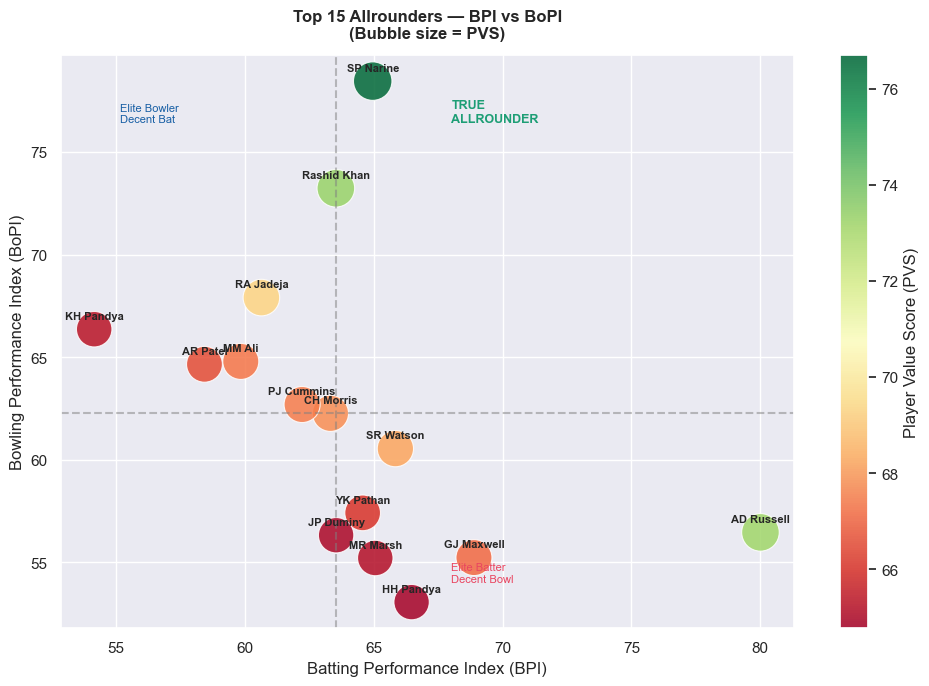

✅ Chart saved → screenshots/05_allrounders.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

# Allrounders only
allrounders = players[players['role'] == 'Allrounder'].dropna(
    subset=['BPI','BoPI']
).nlargest(15, 'PVS')

# Scatter — BPI vs BoPI
scatter = ax.scatter(
    allrounders['BPI'],
    allrounders['BoPI'],
    s=allrounders['PVS'] * 10,
    c=allrounders['PVS'],
    cmap='RdYlGn',
    alpha=0.85,
    edgecolors='white',
    linewidth=0.8
)

# Annotate
for _, row in allrounders.iterrows():
    ax.annotate(
        row['player'],
        (row['BPI'], row['BoPI']),
        fontsize=8, ha='center', va='bottom',
        xytext=(0, 6), textcoords='offset points',
        fontweight='bold'
    )

plt.colorbar(scatter, ax=ax, label='Player Value Score (PVS)')

# Reference lines
ax.axvline(x=allrounders['BPI'].median(),
           color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=allrounders['BoPI'].median(),
           color='gray', linestyle='--', alpha=0.5)

ax.set_title('Top 15 Allrounders — BPI vs BoPI\n(Bubble size = PVS)',
             fontweight='bold', pad=12)
ax.set_xlabel('Batting Performance Index (BPI)')
ax.set_ylabel('Bowling Performance Index (BoPI)')

# Quadrant labels
ax.text(allrounders['BPI'].min()+1,
        allrounders['BoPI'].max()-2,
        'Elite Bowler\nDecent Bat', fontsize=8, color='#185FA5')
ax.text(allrounders['BPI'].max()-12,
        allrounders['BoPI'].max()-2,
        'TRUE\nALLROUNDER', fontsize=9,
        color='#1D9E75', fontweight='bold')
ax.text(allrounders['BPI'].max()-12,
        allrounders['BoPI'].min()+1,
        'Elite Batter\nDecent Bowl', fontsize=8, color='#E94560')

plt.tight_layout()
plt.savefig('../screenshots/05_allrounders.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/05_allrounders.png")

In [7]:
# Final comprehensive export
final_export = players[[
    'overall_rank', 'player', 'role', 'innings',
    'runs_scored', 'strike_rate', 'batting_avg',
    'consistency_score', 'recent_sr', 'BPI',
    'matches', 'wickets', 'economy', 'dot_pct',
    'recent_economy', 'BoPI', 'PVS'
]].copy()

# Add valuation for players with auction prices
final_export = final_export.merge(
    valued[['player','auction_price','value_ratio','valuation']],
    on='player', how='left'
)

final_export.to_csv('../data/processed/player_index.csv', index=False)

# Summary stats
print(f"✅ Player Index exported → data/processed/player_index.csv")
print(f"   Total players  : {len(final_export)}")
print(f"   Batters        : {(final_export['role']=='Batter').sum()}")
print(f"   Bowlers        : {(final_export['role']=='Bowler').sum()}")
print(f"   Allrounders    : {(final_export['role']=='Allrounder').sum()}")
print(f"   With valuation : {final_export['valuation'].notna().sum()}")
print(f"\n=== AUCTIONIQ FINAL RANKINGS — TOP 10 ===")
print(final_export.head(10)[
    ['overall_rank','player','role','PVS','valuation']
].to_string(index=False))
print(f"\nNext → 04_dashboard_prep.ipynb")

✅ Player Index exported → data/processed/player_index.csv
   Total players  : 306
   Batters        : 148
   Bowlers        : 77
   Allrounders    : 81
   With valuation : 30

=== AUCTIONIQ FINAL RANKINGS — TOP 10 ===
 overall_rank          player   role   PVS       valuation
            1       H Klaasen Batter 86.12             NaN
            2        TH David Batter 83.83             NaN
            3         PD Salt Batter 83.19             NaN
            4 B Sai Sudharsan Batter 82.92   Undervalued 💎
            5      Naman Dhir Batter 82.32             NaN
            6        T Stubbs Batter 82.23             NaN
            7        CV Varun Bowler 80.37   Undervalued 💎
            8     YBK Jaiswal Batter 80.14 Premium Value ⭐
            9         TM Head Batter 79.97             NaN
           10  Shashank Singh Batter 79.38             NaN

Next → 04_dashboard_prep.ipynb
